In [7]:
import os, sys
if not os.path.exists("data_clean_utils.py"):
    !git clone https://github.com/Akashkar00/Swiggy-Delivery-Time-Prediction.git
    os.chdir("Swiggy-Delivery-Time-Prediction")
!pip install -q -r requirements.txt
sys.path.insert(0, os.getcwd())


Cloning into 'Swiggy-Delivery-Time-Prediction'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 23 (delta 3), reused 23 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 9.10 MiB | 5.59 MiB/s, done.
Resolving deltas: 100% (3/3), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.4 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import data_clean_utils
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [9]:
from sklearn import set_config

set_config(transform_output="pandas")

# Load the Data

In [10]:
# load the data

df = pd.read_csv('swiggy.csv')

# Clean Data

In [11]:
data_clean_utils.perform_data_cleaning(df)

In [12]:
# load the cleaned data

df = pd.read_csv('swiggy_cleaned.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [13]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [14]:
# drop columns not required for model input
# order_date is kept for now - needed for a chronological train/test split -
# and dropped right after the split.
# pickup_time_minutes is dropped: it isn't known at prediction time (the
# order hasn't been picked up yet) and has ~0 correlation with the target.

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    "order_time_hour",
                    "order_day",
                    "pickup_time_minutes"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_month,order_day_of_week,is_weekend,order_time_of_day,distance,distance_type
0,37.0,4.9,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,3,saturday,1,morning,3.025149,short
1,34.0,4.5,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,3,friday,0,evening,20.183530,very_long
2,23.0,4.4,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,3,saturday,1,morning,1.552758,short
3,38.0,4.7,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,4,tuesday,0,evening,7.790401,medium
4,32.0,4.6,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,3,saturday,1,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,2022-03-24,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,3,thursday,0,morning,1.489846,short
45498,21.0,4.6,2022-02-16,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,2,wednesday,0,evening,NaN,NaN
45499,30.0,4.9,2022-03-11,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,3,friday,0,night,4.657195,short
45500,20.0,4.7,2022-03-07,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,3,monday,0,afternoon,6.232393,medium


In [15]:
# check for missing values

df.isna().sum()

,0
age,1854
ratings,1908
order_date,0
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228


In [16]:
# check for duplicates

df.duplicated().sum()

np.int64(0)

<Axes: >

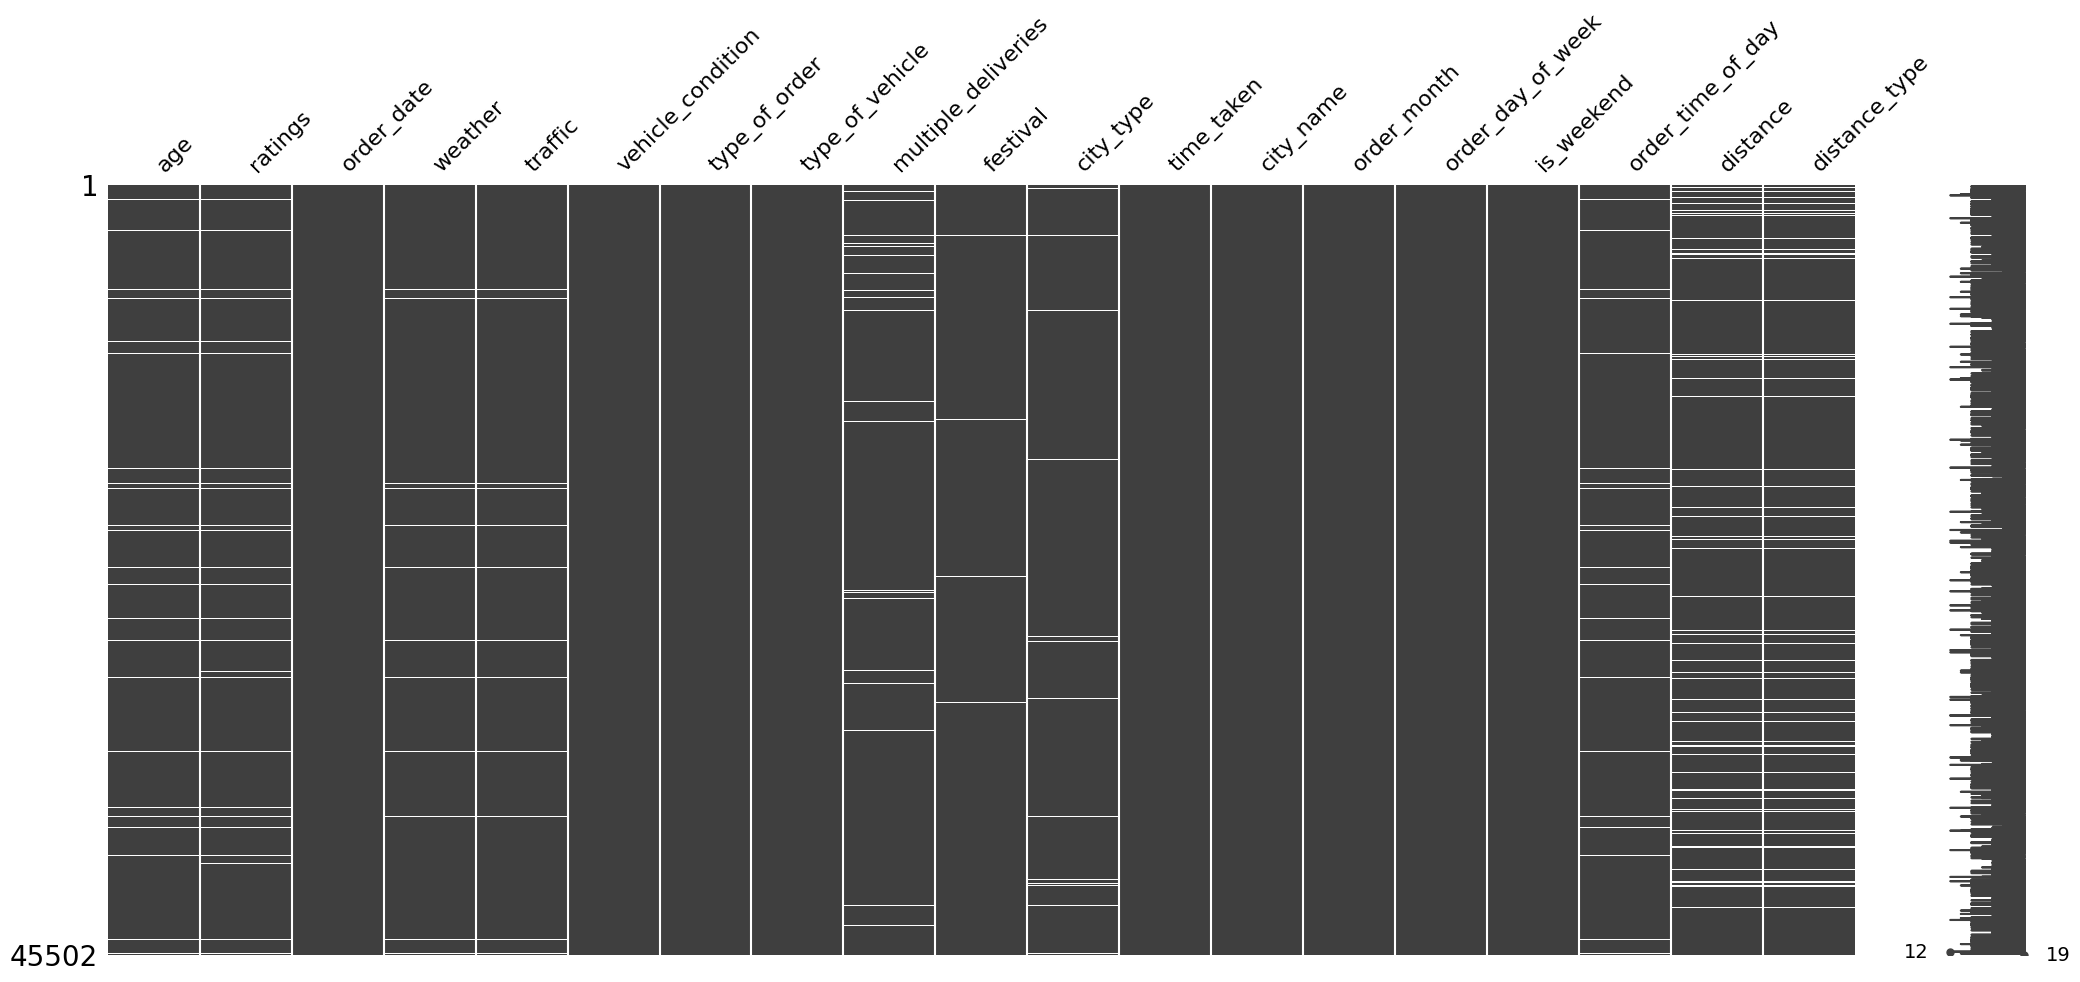

In [17]:
import missingno as msno

msno.matrix(df)

In [18]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

# Data Preparation

In [19]:
# Chronological train/test split.
#
# The model predicts an ETA for orders that haven't happened yet, so the
# test set must be LATER in time than the training set. A random split
# (the original approach) lets rows from the same day end up on both
# sides, which is closer to interpolation than to the real prediction task.

from model_utils import time_based_split, naive_median_predictions
from ab_test import compare_model_errors

train_df, test_df = time_based_split(df, date_col="order_date", test_size=0.2)

print("train order_date range:", train_df["order_date"].min(), "to", train_df["order_date"].max())
print("test order_date range: ", test_df["order_date"].min(), "to", test_df["order_date"].max())

train_df = train_df.drop(columns="order_date")
test_df = test_df.drop(columns="order_date")

X_train = train_df.drop(columns="time_taken")
y_train = train_df["time_taken"]
X_test = test_df.drop(columns="time_taken")
y_test = test_df["time_taken"]

print("The size of train data is", X_train.shape)
print("The size of test data is", X_test.shape)

X_train

train order_date range: 2022-02-11 to 2022-03-28
test order_date range:  2022-03-29 to 2022-04-06
The size of train data is (36069, 17)
The size of test data is (9433, 17)


,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,order_time_of_day,distance,distance_type
22750,NaN,NaN,NaN,NaN,3,drinks,motorcycle,0.0,no,urban,KOC,2,friday,0,NaN,7.803079,medium
30433,36.0,5.0,sandstorms,medium,0,meal,motorcycle,1.0,no,urban,KOC,2,friday,0,afternoon,6.242485,medium
3749,35.0,5.0,fog,high,1,buffet,scooter,2.0,no,metropolitian,KOC,2,friday,0,afternoon,6.242082,medium
41732,25.0,4.8,stormy,high,2,meal,motorcycle,0.0,no,metropolitian,KOL,2,friday,0,morning,1.513644,short
3753,27.0,4.7,cloudy,low,2,meal,electric_scooter,0.0,no,urban,KNP,2,friday,0,morning,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,35.0,4.4,windy,high,0,meal,motorcycle,0.0,yes,metropolitian,HYD,3,monday,0,morning,1.536833,short
42659,39.0,4.8,sunny,low,1,snack,scooter,0.0,no,urban,CHEN,3,monday,0,night,7.761769,medium
30758,34.0,4.8,sunny,high,1,meal,motorcycle,0.0,no,metropolitian,JAP,3,monday,0,morning,2.979000,short
12853,30.0,4.5,stormy,low,0,meal,motorcycle,0.0,no,metropolitian,MYS,3,monday,0,night,7.772096,medium


**Note:** the original notebook tried a first baseline on rows with missing values dropped. That baseline was evaluated on a different (smaller, non-random) subset of rows than the imputed model further down, so its MAE/R2 weren't actually comparable to the final model's. It's replaced below with a naive baseline evaluated on the exact same test rows as every model in this notebook, which is a fair floor to compare against.

In [20]:
# Naive baseline: always predict the training median delivery time.
# Any real model must beat this by a meaningful margin to be worth using.

from sklearn.metrics import mean_absolute_error, r2_score

naive_preds = naive_median_predictions(y_train, n=len(y_test))
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_r2 = r2_score(y_test, naive_preds)

print(f"Naive baseline test MAE: {naive_mae:.2f} minutes")
print(f"Naive baseline test R2:  {naive_r2:.2f}")

Naive baseline test MAE: 7.63 minutes
Naive baseline test R2:  -0.00


# Impute missing values

In [21]:
# missing values in train data

X_train.isna().sum()

,0
age,1464
ratings,1518
weather,412
traffic,397
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,790
festival,173
city_type,950


In [22]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [23]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

In [24]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


np.float64(17.0)

# Age

In [25]:
X_train['age'].describe()

,age
count,34605.000000
mean,29.556538
std,5.760073
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


In [26]:
# missing values in the column

X_train['age'].isna().sum()

np.int64(1464)

In [27]:
# median value

age_median = X_train['age'].median()

**Avg and Median values are similar, impute the age column with median value**

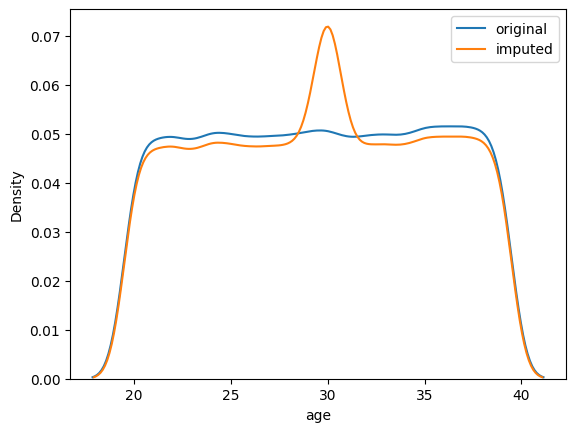

In [28]:
# plot the kde plot

sns.kdeplot(X_train['age'],label="original")
sns.kdeplot(X_train['age'].fillna(age_median),label="imputed")
plt.legend()

**Observation**:

1. Changed the distribution of the age column.
2. Use Advanced imputation techniques like KNN imputer.

## Ratings

In [29]:
# statistical summary

X_train['ratings'].describe()

,ratings
count,34551.000000
mean,4.636890
std,0.312527
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


In [30]:
# missing values

X_train['ratings'].isna().sum()

np.int64(1518)

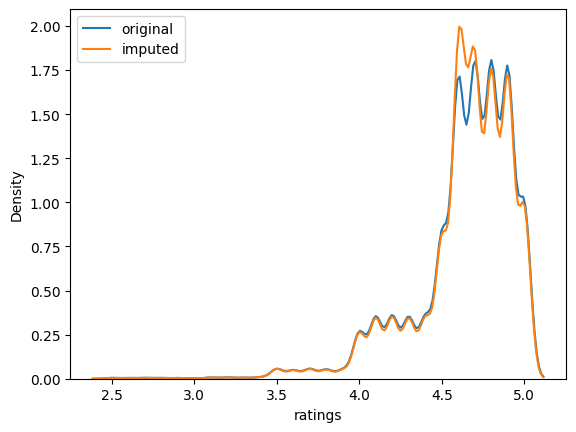

In [31]:
# avg rating

ratings_mean = X_train['ratings'].mean()

# fill and plot kdeplot

sns.kdeplot(X_train['ratings'],label="original")
sns.kdeplot(X_train['ratings'].fillna(ratings_mean),label="imputed")
plt.legend()

# Weather

In [32]:
# value counts

X_train['weather'].value_counts()

,count
weather,
stormy,6057
fog,6031
cloudy,6019
sandstorms,5949
windy,5825
sunny,5776


In [33]:
# missing values in the column

X_train['weather'].isna().sum()

np.int64(412)

<Axes: xlabel='count', ylabel='weather'>

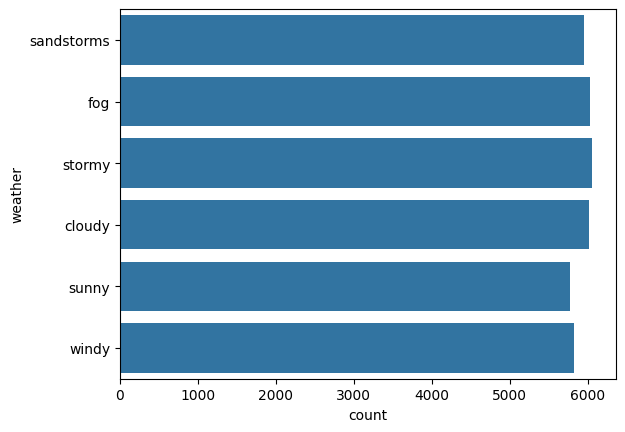

In [34]:
# countplot

sns.countplot(X_train['weather'])

**No dominant category to impute from**


In [35]:
# capture the missingness

missing_weather = MissingIndicator()
missing_weather.set_output(transform="pandas")

pd.concat([X_train['weather'],missing_weather.fit_transform(X_train[['weather']])],axis=1).sample(50)


,weather,missingindicator_weather
33785,stormy,False
22203,sandstorms,False
44422,windy,False
29866,fog,False
10408,stormy,False
11905,cloudy,False
11715,sandstorms,False
33498,sunny,False
35644,sunny,False
8764,windy,False


# Traffic

In [36]:
# value counts

X_train['traffic'].value_counts()

,count
traffic,
low,12318
jam,11167
medium,8632
high,3555


In [37]:
# Missing values in column

X_train['traffic'].isna().sum()

np.int64(397)

<Axes: xlabel='count', ylabel='traffic'>

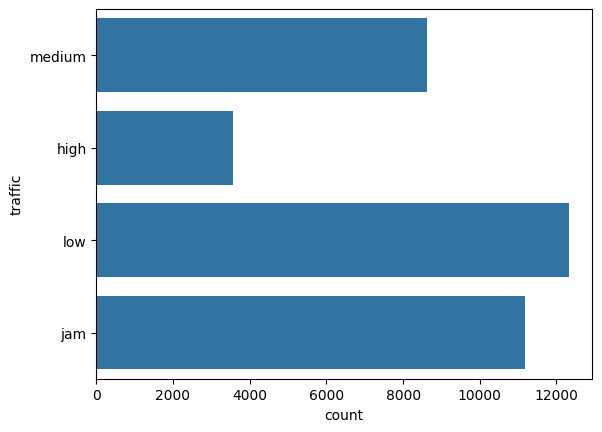

In [38]:
# countplot

sns.countplot(X_train['traffic'])

No Dominant category

In [39]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

# Multiple Deliveries

In [40]:
# value counts

X_train['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1.0,22280
0.0,11157
2.0,1550
3.0,292


<Axes: xlabel='count', ylabel='multiple_deliveries'>

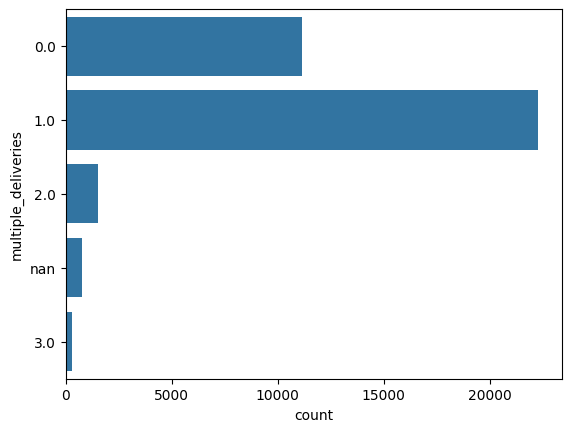

In [41]:
# countplot

sns.countplot(X_train['multiple_deliveries'].apply(str))

In [42]:
# number of missing values

X_train['multiple_deliveries'].isna().sum()

np.int64(790)

In [43]:
# mode value

multiple_deliveries_mode = X_train['multiple_deliveries'].mode()[0]

<Axes: xlabel='count', ylabel='multiple_deliveries'>

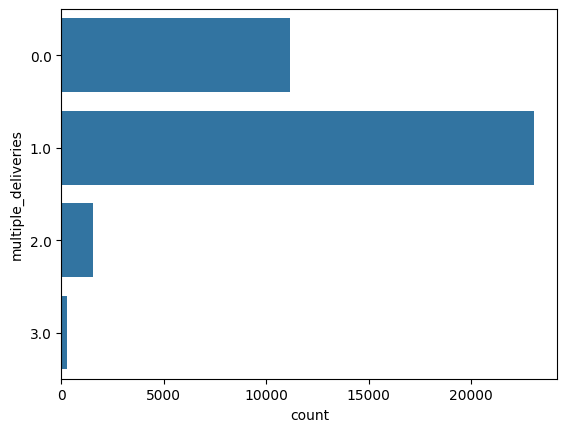

In [44]:
# fill na values with mode

sns.countplot(X_train['multiple_deliveries'].fillna(multiple_deliveries_mode).apply(str))

# Festival

In [45]:
# value counts

X_train['festival'].value_counts()

,count
festival,
no,35197
yes,699


<Axes: xlabel='count', ylabel='festival'>

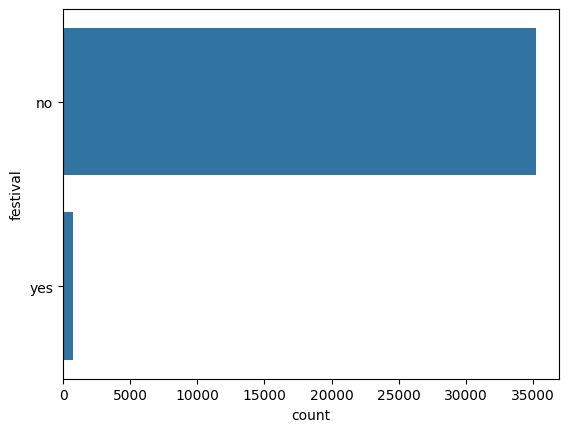

In [46]:
# countplot

sns.countplot(X_train['festival'])

In [47]:
# missing values in column

X_train['festival'].isna().sum()

np.int64(173)

In [48]:
# mode value

festival_mode = X_train['festival'].mode()[0]

<Axes: xlabel='count', ylabel='festival'>

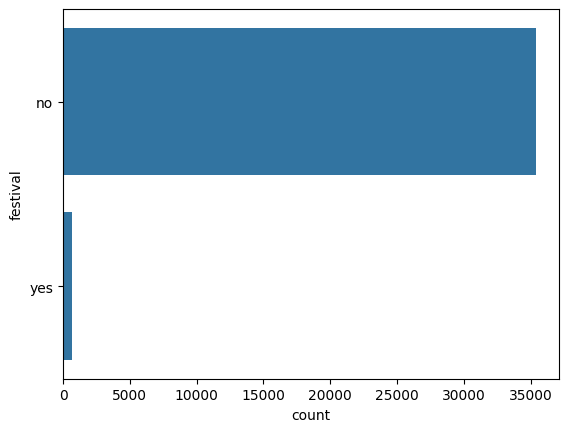

In [49]:
# fill with mode

sns.countplot(X_train['festival'].fillna(festival_mode))

# City type

In [50]:
# value counts

X_train['city_type'].value_counts()

,count
city_type,
metropolitian,26903
urban,8093
semi-urban,123


In [51]:
# number of missing values

X_train['city_type'].isna().sum()

np.int64(950)

<Axes: xlabel='count', ylabel='city_type'>

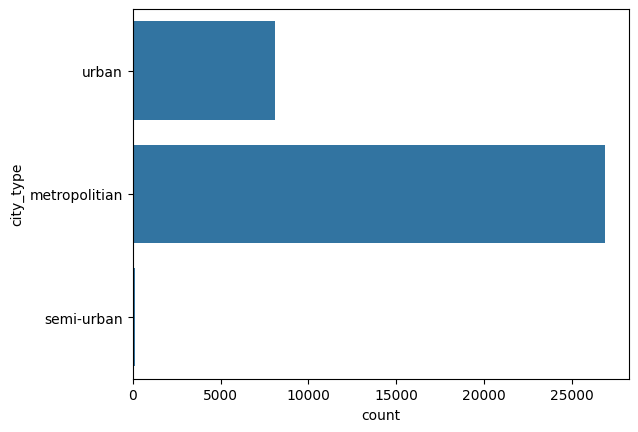

In [52]:
# countplot

sns.countplot(X_train['city_type'])

In [53]:
# mode value

city_type_mode = X_train['city_type'].mode()[0]

<Axes: xlabel='count', ylabel='city_type'>

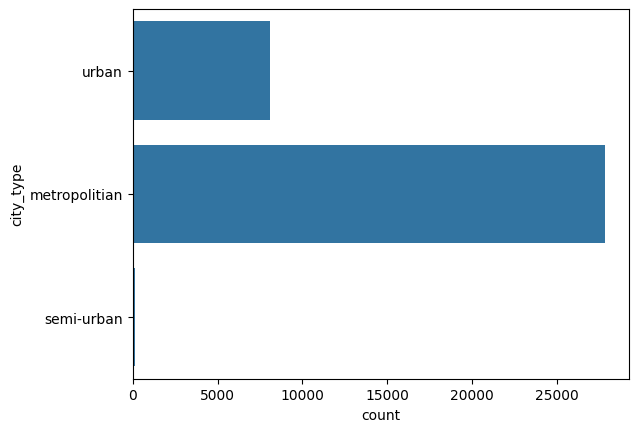

In [54]:
# fill with mode

sns.countplot(X_train['city_type'].fillna(city_type_mode))

In [55]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

# Pickup time minutes

Dropped entirely - it isn't known at prediction time (the order hasn't been picked up yet) and had ~0 correlation with the target anyway, so it's not in `X_train` any more.

# Order time of day

In [56]:
# value counts

X_train['order_time_of_day'].value_counts()

,count
order_time_of_day,
night,10795
evening,10710
morning,7001
afternoon,5915
after_midnight,345


In [57]:
# missing values

X_train['order_time_of_day'].isna().sum()

np.int64(1303)

<Axes: xlabel='count', ylabel='order_time_of_day'>

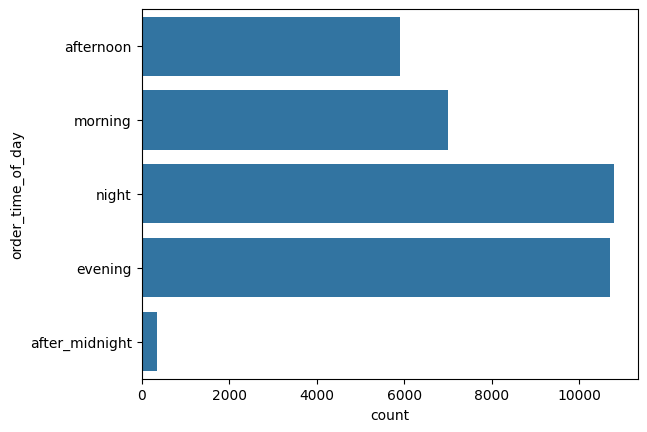

In [58]:
# countplot

sns.countplot(X_train['order_time_of_day'])

In [59]:
# rows where the data is missing

X_train[X_train['order_time_of_day'].isna()]

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,order_time_of_day,distance,distance_type
22750,NaN,NaN,NaN,NaN,3,drinks,motorcycle,0.0,no,urban,KOC,2,friday,0,NaN,7.803079,medium
856,NaN,NaN,sunny,low,0,snack,motorcycle,1.0,no,metropolitian,KOL,2,friday,0,NaN,4.540569,short
1059,NaN,NaN,fog,low,1,buffet,motorcycle,1.0,no,urban,KNP,2,friday,0,NaN,1.492312,short
41315,NaN,NaN,NaN,NaN,3,snack,electric_scooter,1.0,no,metropolitian,KNP,2,friday,0,NaN,2.984667,short
8748,NaN,NaN,sandstorms,low,2,drinks,motorcycle,1.0,no,NaN,KOC,2,friday,0,NaN,3.121360,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24232,NaN,NaN,NaN,NaN,3,meal,bicycle,1.0,no,urban,PUNE,3,monday,0,NaN,4.596667,short
45085,NaN,NaN,cloudy,low,2,meal,motorcycle,1.0,no,urban,SUR,3,monday,0,NaN,4.561269,short
29461,NaN,NaN,windy,medium,1,buffet,scooter,0.0,no,metropolitian,MYS,3,monday,0,NaN,7.772344,medium
12432,NaN,NaN,cloudy,high,0,buffet,motorcycle,1.0,no,urban,RANCHI,3,monday,0,NaN,6.037558,medium


# Distance

In [60]:
# statistical summary

X_train['distance'].describe()

,distance
count,33033.000000
mean,9.588137
std,5.594571
min,1.465067
25%,4.656902
50%,9.122017
75%,13.611567
max,20.969489


In [61]:
# number of missing values

X_train['distance'].isna().sum()

np.int64(3036)

In [62]:
# avg distance

distance_mean = X_train['distance'].mean()

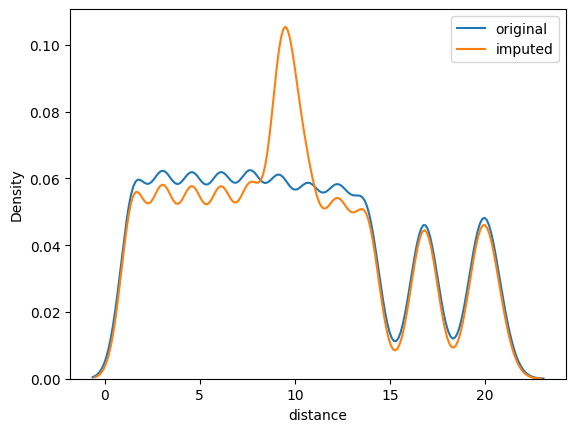

In [63]:
# kdeplot

sns.kdeplot(X_train['distance'],label='original')
sns.kdeplot(X_train['distance'].fillna(distance_mean),label='imputed')
plt.legend()

In [64]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

# Distance Type


In [65]:
# value counts

X_train['distance_type'].value_counts()

,count
distance_type,
short,9142
medium,9112
long,8614
very_long,6165


In [66]:
# missing values

X_train['distance_type'].isna().sum()

np.int64(3036)

<Axes: xlabel='count', ylabel='distance_type'>

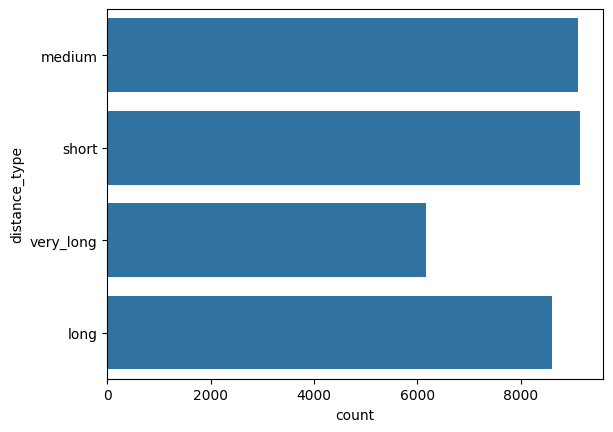

In [67]:
# countplot

sns.countplot(X_train['distance_type'])

Mode cannot be used here

# Imputation Pipeline

In [68]:
# do basic preprocessing

num_cols = ["age","ratings","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type","city_name","order_month",
                    "order_day_of_week",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [69]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day']

In [70]:
X_train.isna().sum()

,0
age,1464
ratings,1518
weather,412
traffic,397
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,790
festival,173
city_type,950


In [71]:
# features to fill values with mode

features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'type_of_order',
 'type_of_vehicle',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day']

In [72]:
# simple imputer to fill categorical vars with mode

simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'festival',
                                  'city_type']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'city_name', 'order_month',
                                  'order_day_of_week', 'is_weekend',
                                  'order_time_of_day'])],
                  verbose_feature_names_out=False)

In [73]:
simple_imputer.fit_transform(X_train)

,multiple_deliveries,festival,city_type,weather,type_of_order,type_of_vehicle,city_name,order_month,order_day_of_week,is_weekend,order_time_of_day,age,ratings,traffic,vehicle_condition,distance,distance_type
22750,0.0,no,urban,missing,drinks,motorcycle,KOC,2,friday,0,missing,NaN,NaN,NaN,3,7.803079,medium
30433,1.0,no,urban,sandstorms,meal,motorcycle,KOC,2,friday,0,afternoon,36.0,5.0,medium,0,6.242485,medium
3749,2.0,no,metropolitian,fog,buffet,scooter,KOC,2,friday,0,afternoon,35.0,5.0,high,1,6.242082,medium
41732,0.0,no,metropolitian,stormy,meal,motorcycle,KOL,2,friday,0,morning,25.0,4.8,high,2,1.513644,short
3753,0.0,no,urban,cloudy,meal,electric_scooter,KNP,2,friday,0,morning,27.0,4.7,low,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,0.0,yes,metropolitian,windy,meal,motorcycle,HYD,3,monday,0,morning,35.0,4.4,high,0,1.536833,short
42659,0.0,no,urban,sunny,snack,scooter,CHEN,3,monday,0,night,39.0,4.8,low,1,7.761769,medium
30758,0.0,no,metropolitian,sunny,meal,motorcycle,JAP,3,monday,0,morning,34.0,4.8,high,1,2.979000,short
12853,0.0,no,metropolitian,stormy,meal,motorcycle,MYS,3,monday,0,night,30.0,4.5,low,0,7.772096,medium


In [74]:
simple_imputer.fit_transform(X_train).isna().sum()

,0
multiple_deliveries,0
festival,0
city_type,0
weather,0
type_of_order,0
type_of_vehicle,0
city_name,0
order_month,0
order_day_of_week,0
is_weekend,0


In [75]:
# knn imputer

knn_imputer = KNNImputer(n_neighbors=5)

In [76]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [77]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic [nan 'medium' 'high' 'low' 'jam']
distance_type ['medium' 'short' nan 'very_long' 'long']


In [78]:
# build a preprocessor
#
# encoded_missing_value / unknown_value are set to NaN, not a magic number
# like -999. Every other column here is scaled to roughly [0, 1]; a -999
# sentinel would sit far outside that range and get treated by the
# downstream KNNImputer as a real, enormous distance instead of "missing".

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=np.nan,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=np.nan), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'city_name',
                                  'order_month', 'order_day_of_week',
                                  'is_weekend', 'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=nan),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [79]:
preprocessor.fit_transform(X_train)

,age,ratings,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,weather_nan,type_of_order_drinks,...,is_weekend_1,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,traffic,distance_type,vehicle_condition,multiple_deliveries
22750,NaN,NaN,0.324953,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1.0,3,0.0
30433,0.842105,1.00,0.244940,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0,1.0
3749,0.789474,1.00,0.244920,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1,2.0
41732,0.263158,0.92,0.002491,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,2,0.0
3753,0.368421,0.88,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,0.789474,0.76,0.003679,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0,0.0
42659,1.000000,0.92,0.322835,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1,0.0
30758,0.736842,0.92,0.077620,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1,0.0
12853,0.526316,0.80,0.323364,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0,0.0


In [80]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda ser : ser.ge(1)]

,0
age,1464
ratings,1518
distance,3036
traffic,397
distance_type,3036
multiple_deliveries,790


In [81]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'festival', 'city_type']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehi...
                                                   'festival', 'city_type',
                                                   'city_name', 'order_month',
                                                   'order_day_of_week',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=nan),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [82]:
# fit and transform the pipeline on X_train

processing_pipeline.fit_transform(X_train)

,age,ratings,distance,weather_fog,weather_missing,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,is_weekend_1,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_missing,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,multiple_deliveries,vehicle_condition
22750,0.589474,0.856,0.324953,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.6,1.0,0.0,3.0
30433,0.842105,1.000,0.244940,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3749,0.789474,1.000,0.244920,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,1.0
41732,0.263158,0.920,0.002491,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,2.0
3753,0.368421,0.880,0.033501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23498,0.789474,0.760,0.003679,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0
42659,1.000000,0.920,0.322835,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
30758,0.736842,0.920,0.077620,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0
12853,0.526316,0.800,0.323364,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [83]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",lr)
                            ])
model_pipe = lr_pipe

lr_pipe

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                    'order_month',
                                                                    'order_day_of_week',
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [84]:
# fit the pipeline on data

lr_pipe.fit(X_train, y_train_pt)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                    'order_month',
                                                                    'order_day_of_week',
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [85]:
# get the predictions
y_pred_train = lr_pipe.predict(X_train)
y_pred_test = lr_pipe.predict(X_test)

In [86]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))
lr_y_pred_test_org = y_pred_test_org

In [87]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print(f"The train MAE is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test MAE is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")
print(f"The train RMSE is {root_mean_squared_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test RMSE is {root_mean_squared_error(y_test,y_pred_test_org):.2f} minutes")

The train MAE is 4.79 minutes
The test MAE is 4.81 minutes
The train RMSE is 6.02 minutes
The test RMSE is 6.06 minutes


In [88]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.59
The test r2 score is 0.59


In [89]:
# Random Forest, lightly tuned with cross-validated random search instead
# of a single fit on default hyperparameters (which overfit badly: the
# original notebook got train R2 0.97 vs test R2 0.80 - a large gap that
# means the model partly memorized the training rows).

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", 0.5, 1.0],
}

rf_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",RandomForestRegressor(random_state=42,n_jobs=-1))
                            ])

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_distributions, n_iter=8, cv=3,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_pt.values.ravel())

model_pipe = rf_search.best_estimator_
rf_pipe = model_pipe
print("Random Forest best params:", rf_search.best_params_)

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 16}


In [90]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [91]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
rf_y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [92]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print(f"The train MAE is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test MAE is {mean_absolute_error(y_test,rf_y_pred_test_org):.2f} minutes")
print(f"The train RMSE is {root_mean_squared_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test RMSE is {root_mean_squared_error(y_test,rf_y_pred_test_org):.2f} minutes")

The train MAE is 2.18 minutes
The test MAE is 3.32 minutes
The train RMSE is 2.77 minutes
The test RMSE is 4.21 minutes


In [93]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,rf_y_pred_test_org):.2f}")

The train r2 score is 0.91
The test r2 score is 0.80


# XGBoost

In [94]:
# Detect whether a GPU is available in this runtime (Colab: Runtime >
# Change runtime type > GPU) and use it if so; XGBoost trains on CPU
# just as correctly, only slower, if none is found.

import subprocess

try:
    subprocess.run(["nvidia-smi"], check=True, capture_output=True)
    xgb_device = "cuda"
except Exception:
    xgb_device = "cpu"

print("XGBoost device:", xgb_device)

XGBoost device: cuda


In [95]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",XGBRegressor(
                                    n_estimators=400,
                                    max_depth=6,
                                    learning_rate=0.05,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    tree_method="hist",
                                    device=xgb_device,
                                    random_state=42,
                                ))
                            ])

xgb_pipe.fit(X_train, y_train_pt.values.ravel())

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=400, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [96]:
# get the predictions
y_pred_train = xgb_pipe.predict(X_train)
y_pred_test = xgb_pipe.predict(X_test)

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [06:35:39] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [97]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
xgb_y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [98]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print(f"The train MAE is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test MAE is {mean_absolute_error(y_test,xgb_y_pred_test_org):.2f} minutes")
print(f"The train RMSE is {root_mean_squared_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test RMSE is {root_mean_squared_error(y_test,xgb_y_pred_test_org):.2f} minutes")

The train MAE is 2.91 minutes
The test MAE is 3.34 minutes
The train RMSE is 3.66 minutes
The test RMSE is 4.22 minutes


In [99]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,xgb_y_pred_test_org):.2f}")

The train r2 score is 0.85
The test r2 score is 0.80


# LightGBM

Runs on CPU here: GPU LightGBM needs a special build (`pip install lightgbm --config-settings=cmake.define.USE_GPU=ON`, or a CUDA build) that isn't guaranteed to be present on a stock Colab image, and its own histogram-based CPU training is already fast.

In [100]:
from lightgbm import LGBMRegressor

lgbm_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",LGBMRegressor(
                                    n_estimators=400,
                                    max_depth=6,
                                    learning_rate=0.05,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    random_state=42,
                                    n_jobs=-1,
                                    verbosity=-1,
                                ))
                            ])

lgbm_pipe.fit(X_train, y_train_pt.values.ravel())

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05,
                               max_depth=6, n_estimators=400, n_jobs=-1,
                               random_state=42, subsample=0.8, verbosity=-1))])

In [101]:
# get the predictions
y_pred_train = lgbm_pipe.predict(X_train)
y_pred_test = lgbm_pipe.predict(X_test)

In [102]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
lgbm_y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [105]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

print(f"The train MAE is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test MAE is {mean_absolute_error(y_test,lgbm_y_pred_test_org):.2f} minutes")
print(f"The train RMSE is {root_mean_squared_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test RMSE is {root_mean_squared_error(y_test,lgbm_y_pred_test_org):.2f} minutes")

The train MAE is 3.09 minutes
The test MAE is 3.35 minutes
The train RMSE is 3.88 minutes
The test RMSE is 4.24 minutes


In [106]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,lgbm_y_pred_test_org):.2f}")

The train r2 score is 0.83
The test r2 score is 0.80


# Model Tournament (A/B Testing)

In [107]:
# Champion/challenger tournament: each new model must beat the current
# champion by a STATISTICALLY SIGNIFICANT margin (paired Wilcoxon
# signed-rank test on the same held-out test rows) to take the title -
# not just have a numerically lower MAE, which could be noise.

candidates = [
    ("linear_regression", lr_pipe, lr_y_pred_test_org),
    ("random_forest", rf_pipe, rf_y_pred_test_org),
    ("xgboost", xgb_pipe, xgb_y_pred_test_org),
    ("lightgbm", lgbm_pipe, lgbm_y_pred_test_org),
]

champion_name, champion_pipe, champion_preds = candidates[0]
champion_errors = np.abs(y_test.values - champion_preds.ravel())

for challenger_name, challenger_pipe, challenger_preds in candidates[1:]:
    challenger_errors = np.abs(y_test.values - challenger_preds.ravel())
    result = compare_model_errors(
        champion_errors, challenger_errors,
        model_a_name=champion_name, model_b_name=challenger_name,
    )
    print(f"{champion_name} vs {challenger_name}: {result}")
    if result["better_model"] == challenger_name:
        champion_name, champion_pipe, champion_errors = challenger_name, challenger_pipe, challenger_errors

print("\nFinal champion:", champion_name)

linear_regression vs random_forest: {'mean_error_a': 4.812581404445309, 'mean_error_b': 3.3183288640250446, 'p_value': 1.1610970492720186e-292, 'significant': True, 'better_model': 'random_forest'}
random_forest vs xgboost: {'mean_error_a': 3.3183288640250446, 'mean_error_b': 3.3355748483816967, 'p_value': 0.7293228846154727, 'significant': False, 'better_model': None}
random_forest vs lightgbm: {'mean_error_a': 3.3183288640250446, 'mean_error_b': 3.345724693541477, 'p_value': 0.5309153238384561, 'significant': False, 'better_model': None}

Final champion: random_forest


**Reading the result:** `significant: True` means the challenger's lower error is very unlikely to be due to chance on this test set, and it becomes the new champion. `better_model: None` means the difference isn't statistically reliable, so the current champion is kept.

In [108]:
# save the winning model

import joblib

joblib.dump({"pipeline": champion_pipe, "power_transformer": pt}, "model.joblib")
print("saved model.joblib, winner:", champion_name)

saved model.joblib, winner: random_forest
